# GDP-deflator (PGDP) ranking CIs

Same procedure as `NGDP_CI` / `UNEMP_CI`, but for the SPF GDP-deflator panel:
- **Forecasts**: `Individual_PGDP.xlsx`, sheet `PGDP` (PGDP1..PGDP6) — quarterly price-level forecasts.
- **Realizations**: `PQvQd.xlsx` — quarterly RTDSM vintage matrix with prefix `P`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    rank_confidence_intervals_simulation_pairwise,
    rank_ci_stepwise_simulation_pairwise,
    rank_ci_marginal_simulation_pairwise,
    compute_pairwise,
    load_spf,
    load_rtdsm,
    compute_errors,
    compute_error_panel,
    select_top_forecasters,
    winsorize_panel,
)
from rankci.data import advance_vintage_col, get_advance_estimate

# Data Loading

In [2]:
df = load_spf("../data/Individual_PGDP.xlsx", sheet="PGDP")
print(f"SPF PGDP: {df.shape[0]} rows \u00d7 {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

SPF PGDP: 9248 rows × 12 columns
Columns: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'PGDP1', 'PGDP2', 'PGDP3', 'PGDP4', 'PGDP5', 'PGDP6', 'PGDPA', 'PGDPB']


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,YEAR,QUARTER,ID,INDUSTRY,PGDP1,PGDP2,PGDP3,PGDP4,PGDP5,PGDP6,PGDPA,PGDPB
0,1968,4,1,NaN,122.0,123.0,124.0,125.0,125.0,126.0,NaN,NaN
1,1968,4,2,NaN,122.0,123.0,124.0,124.0,125.0,126.0,NaN,NaN
2,1968,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,122.0,123.0,124.0,125.0,126.0,127.0,NaN,NaN
4,1968,4,5,NaN,122.0,124.0,125.0,126.0,126.0,127.0,NaN,NaN


In [3]:
p_rtdsm = load_rtdsm("../data/PQvQd.xlsx", prefix="P", freq="quarterly")
print(f"RTDSM (P): {p_rtdsm.shape[0]} quarters \u00d7 {p_rtdsm.shape[1]} vintages")
p_rtdsm.head()

RTDSM (P): 317 quarters × 243 vintages


P65Q4    P66Q1    P66Q2    P66Q3    P66Q4    P67Q1    P67Q2  \
YEAR QUARTER                                                                  
1947 1        72.9765  72.9765  72.9765  72.9765  72.9765  72.9765  72.9765   
     2        73.6570  73.6570  73.6570  73.6570  73.6570  73.6570  73.6570   
     3        74.8708  74.8708  74.8708  74.8708  74.8708  74.8708  74.8708   
     4        76.9793  76.9793  76.9793  76.9793  76.9793  76.9793  76.9793   
1948 1        78.2088  78.2088  78.2088  78.2088  78.2088  78.2088  78.2088   

                P67Q3    P67Q4    P68Q1  ...   P24Q1   P24Q2   P24Q3   P24Q4  \
YEAR QUARTER                             ...                                   
1947 1        72.9765  72.9765  72.9765  ...  11.148  11.148  11.148  11.148   
     2        73.6570  73.6570  73.6570  ...  11.300  11.300  11.300  11.300   
     3        74.8708  74.8708  74.8708  ...  11.478  11.478  11.478  11.478   
     4        76.9793  76.9793  76.9793  ...  11.714  11.714  11.714  11.714   
1948 1        78.2088  78.2088  78.2088  ...  11.849  11.849  11.849  11.849   

               P25Q1   P25Q2   P25Q3   P25Q4   P26Q1   P26Q2  
YEAR QUARTER                                                  
1947 1        11.148  11.148  11.148  11.148  11.148  11.148  
     2        11.300  11.300  11.300  11.300  11.300  11.300  
     3        11.478  11.478  11.478  11.478  11.478  11.478  
     4        11.714  11.714  11.714  11.714  11.714  11.714  
1948 1        11.849  11.849  11.849  11.849  11.849  11.849  

[5 rows x 243 columns]

# Regime restriction (1996+)

The SPF `PGDP` target is not a single concept across the full history:

- **pre-1992**: implicit GNP deflator (fixed-weight)
- **1992 – 1995**: fixed-weight GDP deflator
- **1996+**: chain-weighted GDP price index

Mixing these regimes pools forecasters who were predicting *different objects*. The conservative fix is to restrict the sample to surveys submitted in 1996:Q1 or later, so every forecast is for the chain-weighted index.

In [4]:
START_YEAR = 1996
n_before = len(df)
df = df[df["YEAR"] >= START_YEAR].reset_index(drop=True)
print(f"Restricted to surveys with YEAR >= {START_YEAR}: {n_before} → {len(df)} rows "
      f"({df['YEAR'].min()}:Q{df.loc[df['YEAR'].idxmin(), 'QUARTER']} "
      f"to {df['YEAR'].max()}:Q{df.loc[df['YEAR'].idxmax(), 'QUARTER']})")

Restricted to surveys with YEAR >= 1996: 9248 → 4800 rows (1996:Q1 to 2026:Q1)


# Sanity Checks

In [5]:
# Verify advance PGDP estimates for a few known quarters
test_cases = [(1995, 2), (2008, 4), (2020, 2)]
print(f"{'Target Quarter':<20} {'Vintage Col':<14} {'PGDP (index)'}")
print("-" * 55)
for y, q in test_cases:
    col = advance_vintage_col(y, q, prefix="P")
    val = get_advance_estimate(y, q, p_rtdsm)
    print(f"  {y}:Q{q:<16}  {col:<14}  {val:.3f}")

Target Quarter       Vintage Col    PGDP (index)
-------------------------------------------------------
  1995:Q2                 P95Q3           128.016
  2008:Q4                 P09Q1           123.113
  2020:Q2                 P20Q3           112.858


# Forecast Errors

In [6]:
errors_df = compute_errors(df, p_rtdsm, indicator="PGDP")

print("Error summary by horizon (index points):")
for h in range(1, 7):
    col = f"error_PGDP{h}"
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.2f}, "
              f"std={errors_df[col].std():.2f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

errors_df.head()

Error summary by horizon (index points):
  error_PGDP1: mean=+0.00, std=0.03, nan%=7.7%
  error_PGDP2: mean=+0.42, std=2.36, nan%=7.8%
  error_PGDP3: mean=+0.84, std=3.28, nan%=8.5%
  error_PGDP4: mean=+1.28, std=4.06, nan%=9.2%
  error_PGDP5: mean=+1.77, std=4.73, nan%=10.1%
  error_PGDP6: mean=+2.22, std=5.33, nan%=11.7%


,YEAR,QUARTER,ID,INDUSTRY,error_PGDP1,error_PGDP2,error_PGDP3,error_PGDP4,error_PGDP5,error_PGDP6
0,1996,1,20,2.0,NaN,0.6,0.4,0.8,0.4,-0.04
1,1996,1,40,2.0,NaN,0.2,0.6,0.9,1.1,1.16
2,1996,1,65,1.0,NaN,-0.1,0.0,0.2,0.2,NaN
3,1996,1,84,1.0,NaN,-0.2,0.1,0.3,0.6,NaN
4,1996,1,94,1.0,NaN,0.1,0.2,0.2,0.2,0.06


In [7]:
# Squared error panel for PGDP3 (one-quarter-ahead)
X_wide = compute_error_panel(df, p_rtdsm, indicator="PGDP", horizon=3, metric="squared")
print(f"Panel shape: {X_wide.shape[0]} quarters \u00d7 {X_wide.shape[1]} forecasters")
X_wide.head()

Panel shape: 118 quarters × 153 forecasters


ID               20    40      65      84    94      99        404   405  \
YEAR QUARTER                                                               
1996 1        0.1600  0.36  0.0000  0.0100  0.04     NaN  0.075625   NaN   
     2           NaN   NaN  0.0400  0.1600   NaN  0.1600  0.090000  0.25   
     3        0.0100   NaN  0.0400  0.0100   NaN     NaN  0.090000  0.09   
     4           NaN   NaN  0.5476  0.0256   NaN  0.0036  0.019600   NaN   
1997 1        0.0049   NaN  1.1449  0.0009   NaN     NaN  0.448900   NaN   

ID                 407       409  ...  599  600  601  602  603  605  606  607  \
YEAR QUARTER                      ...                                           
1996 1        0.189225  0.027889  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     2        0.451584       NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     3        0.810000       NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
     4        0.129600       NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1997 1        0.396900       NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

ID            608  609  
YEAR QUARTER            
1996 1        NaN  NaN  
     2        NaN  NaN  
     3        NaN  NaN  
     4        NaN  NaN  
1997 1        NaN  NaN  

[5 rows x 153 columns]

# Forecaster Selection

In [8]:
obs_counts = X_wide.notna().sum()
mean_mse = X_wide.mean()

stats = pd.DataFrame({
    "obs_count": obs_counts,
    "mean_mse":  mean_mse,
    "rmse":      np.sqrt(mean_mse),
}).sort_values("obs_count", ascending=False)

print(f"Total forecasters: {len(stats)}")
print(f"Forecasters with >= 20 obs: {(stats['obs_count'] >= 20).sum()}")
print(f"Forecasters with >= 50 obs: {(stats['obs_count'] >= 50).sum()}")
stats.head(20)

Total forecasters: 153
Forecasters with >= 20 obs: 70
Forecasters with >= 50 obs: 38


,obs_count,mean_mse,rmse
ID,,,
510,104,11.665100,3.415421
426,102,12.647024,3.556265
463,101,11.620194,3.408841
484,100,10.609970,3.257295
428,100,12.145117,3.484984
433,98,9.550642,3.090411
411,98,11.007337,3.317731
421,97,11.253565,3.354633
504,95,14.122399,3.757978


In [9]:
N = 8
X_panel = select_top_forecasters(X_wide, N=N, min_obs=20)
print(f"Selected {X_panel.shape[1]} forecasters, {X_panel.shape[0]} quarters")
print(f"Forecaster IDs: {X_panel.columns.tolist()}")

Selected 8 forecasters, 118 quarters
Forecaster IDs: [510, 426, 463, 428, 484, 411, 433, 421]


# Rank Confidence Intervals

In [10]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(4),
    "RMSE":       np.sqrt(out["theta_hat"]).round(4),
    "CI_lower":   out["rank_ci"][:, 0],
    "CI_upper":   out["rank_ci"][:, 1],
}).sort_values("MSE")
results.index = range(1, len(results) + 1)
results.index.name = "Rank"
results

=== Pairwise shared observations ===
  Min: 80, Mean: 84.6, Max: 89
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 2.5440, Pairs with t > 1.96: 3


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,433,9.5506,3.0904,1,8
2,484,10.6100,3.2573,1,8
3,411,11.0073,3.3177,1,8
4,421,11.2536,3.3546,1,8
5,463,11.6202,3.4088,1,8
6,510,11.6651,3.4154,1,8
7,428,12.1451,3.4850,1,8
8,426,12.6470,3.5563,1,8


# Worst-Quarter Inspection

Time coverage: (1996, 1) to (2025, 4) (118 quarters)

Top 10 quarters with highest average squared error:
YEAR  QUARTER
2009  2          217.666547
      1          192.896333
2013  1          119.649396
      2          116.696032
2023  3          104.657123
1999  3           99.417030
2023  2           99.113678
1999  2           97.079254
2003  3           45.447034
      4           44.814440
dtype: float64


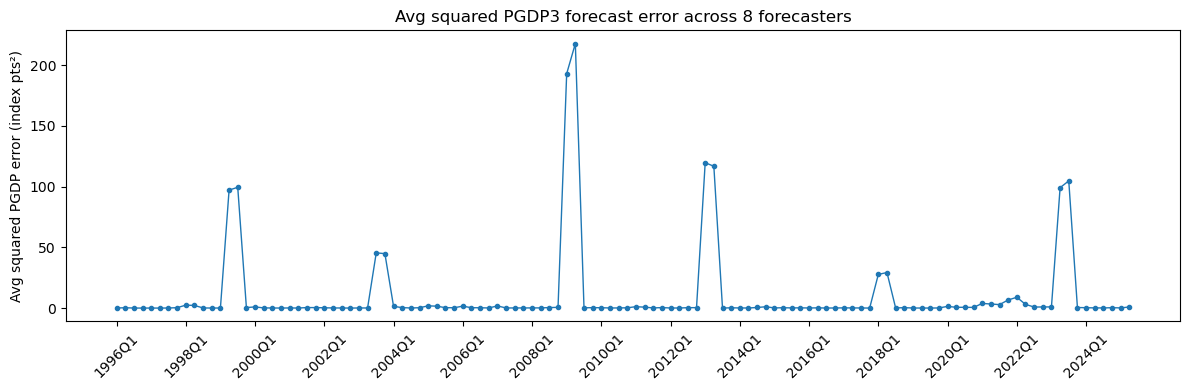

In [11]:
period_mse = X_panel.mean(axis=1)

print(f"Time coverage: {X_panel.index[0]} to {X_panel.index[-1]} ({len(X_panel)} quarters)\n")
print("Top 10 quarters with highest average squared error:")
print(period_mse.nlargest(10))

n = len(X_panel)
plt.figure(figsize=(12, 4))
plt.plot(range(n), period_mse, marker="o", linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 8),
    labels=[f"{y}Q{q}" for y, q in X_panel.index[::8]],
    rotation=45,
)
plt.ylabel("Avg squared PGDP error (index pts\u00b2)")
plt.title(f"Avg squared PGDP3 forecast error across {N} forecasters")
plt.tight_layout()
plt.show()

# Winsorization (variant 2: pairwise differences)

In [12]:
print("=== Winsorize pairwise differences ===")
print(f"{'winsor_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for winsor_pct in [99, 97, 95, 90]:
    delta_w, se_w, _ = compute_pairwise(X, se_method="nw", winsor_pct=winsor_pct)
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(
        X, alpha=0.05, B=1000, seed=42, winsor_pct=winsor_pct, verbose=False,
    )
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]

    print(f"  {winsor_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Winsorize pairwise differences ===
winsor_pct   max_t      mean CI width   
----------------------------------------
  99         2.614      7.00            
  97         3.180      7.00            
  95         3.383      7.00            
  90         3.717      7.00            


# Marginal Rank Confidence Intervals

Per-forecaster CIs that control coverage marginally (no joint family-wise error control).

In [13]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    "ID":       population_ids,
    "MSE":      out_marg["theta_hat"].round(4),
    "RMSE":     np.sqrt(out_marg["theta_hat"]).round(4),
    "cv_j":     out_marg["critical_values"].round(3),
    "CI_lower": out_marg["rank_ci"][:, 0],
    "CI_upper": out_marg["rank_ci"][:, 1],
}).sort_values("MSE")
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = "Rank"
results_marg

,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,433,9.5506,3.0904,2.774,1,8
2,484,10.6100,3.2573,2.602,1,8
3,411,11.0073,3.3177,2.296,1,6
4,421,11.2536,3.3546,2.505,2,8
5,463,11.6202,3.4088,2.358,1,8
6,510,11.6651,3.4154,2.690,1,8
7,428,12.1451,3.4850,2.264,1,8
8,426,12.6470,3.5563,2.470,1,8


# Sensitivity to NW bandwidth `L`

Sweep `L \u2208 {auto, 1, 2, 4, 8, 20}` for the marginal procedure.

In [14]:
L_values = [None, 1, 2, 4, 8, 20]

ci_by_L = {}
maxt_by_L = {}
for L in L_values:
    delta, se, _ = compute_pairwise(X, se_method="nw", L=L)
    maxt_by_L[L] = float(np.nanmax(delta / se))
    out_L = rank_ci_marginal_pairwise(X, alpha=0.05, B=2000, seed=42, L=L)
    ci_by_L[L] = out_L["rank_ci"]

order = np.argsort(out_marg["theta_hat"])
ordered_ids = [population_ids[i] for i in order]

table_L = pd.DataFrame(
    {
        f"L={L if L is not None else 'auto'}":
            [f"[{ci_by_L[L][i, 0]},{ci_by_L[L][i, 1]}]" for i in order]
        for L in L_values
    },
    index=ordered_ids,
)
table_L.index.name = "ID"

print("max test stat by L:")
for L, t in maxt_by_L.items():
    label = "auto" if L is None else str(L)
    print(f"  L={label:<5}  max_t = {t:.3f}")
print()
table_L

max test stat by L:
  L=auto   max_t = 2.544
  L=1      max_t = 2.494
  L=2      max_t = 2.515
  L=4      max_t = 2.594
  L=8      max_t = 2.994
  L=20     max_t = 3.593



,L=auto,L=1,L=2,L=4,L=8,L=20
ID,,,,,,
433,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
484,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
411,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
421,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[2,8]"
463,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
510,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
428,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
426,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"


# MAE-based ranking

In [15]:
N      = 5
alpha  = 0.2
L      = None

# MAE
X_mae_wide  = compute_error_panel(df, p_rtdsm, indicator="PGDP", horizon=3, metric="absolute")
X_mae_panel = select_top_forecasters(X_mae_wide, N=N, min_obs=20)
X_mae       = X_mae_panel.values
ids_mae     = X_mae_panel.columns.tolist()

out_mae = rank_ci_marginal_pairwise(X_mae, alpha=alpha, B=5000, seed=42, L=L)

# MSE \u2014 same forecasters, same alpha/L, but using squared errors
X_mse_wide  = compute_error_panel(df, p_rtdsm, indicator="PGDP", horizon=3, metric="squared")
X_mse_panel = select_top_forecasters(X_mse_wide, N=N, min_obs=20)
X_mse       = X_mse_panel.values
ids_mse     = X_mse_panel.columns.tolist()

out_mse = rank_ci_marginal_pairwise(X_mse, alpha=alpha, B=5000, seed=42, L=L)

order = np.argsort(out_mae["theta_hat"])

results_compare = pd.DataFrame({
    "ID":       [ids_mae[i] for i in order],
    "MAE":      out_mae["theta_hat"][order].round(3),
    "MSE":      out_mse["theta_hat"][order].round(4),
    "CI_MAE":   [f"[{l},{u}]" for l, u in out_mae["rank_ci"][order]],
    "CI_MSE":   [f"[{l},{u}]" for l, u in out_mse["rank_ci"][order]],
})
results_compare.index = range(1, len(results_compare) + 1)
results_compare.index.name = "MAE_rank"
results_compare

,ID,MAE,MSE,CI_MAE,CI_MSE
MAE_rank,,,,,
1,463,1.460,11.6202,"[1,5]","[1,5]"
2,484,1.500,10.6100,"[1,5]","[1,5]"
3,510,1.589,11.6651,"[1,4]","[1,5]"
4,426,1.633,12.6470,"[2,5]","[1,5]"
5,428,1.642,12.1451,"[1,5]","[1,5]"


# τ-best confidence set (Algorithm 3.3)

A forecaster is *included* in the τ-best set iff there is no evidence that — even after exempting any $\tau-1$ others — at least one population outside the exemption is substantially better. We sweep $\tau \in \{1, 2, 3\}$ at $\alpha = 0.2$ and compare Algorithm 3.3 with the naive projection from joint stepwise rank CIs.

In [16]:
from rankci import tau_best_pairwise, tau_best_from_rank_ci

ALPHA_TAU = 0.2
B_TAU     = 5000
SEED_TAU  = 42

X = X_panel.values
population_ids = X_panel.columns.tolist()

out_rank = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows = []
for tau in [1, 2, 3]:
    res = tau_best_pairwise(
        X, tau=tau, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
    )
    naive = tau_best_from_rank_ci(out_rank["rank_ci"], tau=tau)
    rows.append({
        "tau":             tau,
        "n_direct":        int(res["n_in_set"]),
        "set_direct":      [population_ids[j] for j, v in enumerate(res["tau_best_set"]) if v],
        "n_naive":         int(naive.sum()),
        "set_naive":       [population_ids[j] for j, v in enumerate(naive) if v],
        "max_test_stat":   round(float(np.nanmax(res["test_stats"])), 3),
    })

tau_sweep = pd.DataFrame(rows).set_index("tau")
print(f"alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(population_ids)}")
print(f"Forecaster IDs: {population_ids}")
print()
tau_sweep

alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [510, 426, 463, 428, 484, 411, 433, 421]



,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,8,"[510, 426, 463, 428, 484, 411, 433, 421]",8,"[510, 426, 463, 428, 484, 411, 433, 421]",2.544
2,8,"[510, 426, 463, 428, 484, 411, 433, 421]",8,"[510, 426, 463, 428, 484, 411, 433, 421]",2.466
3,8,"[510, 426, 463, 428, 484, 411, 433, 421]",8,"[510, 426, 463, 428, 484, 411, 433, 421]",1.881
